# **Data Visualisation**

## Objectives

* Produce the visualisations that answer each stated business requirement
* Use at least four distinct chart types, each chosen to suit the data being shown
* Apply a colourblind-safe palette and direct data labelling so that no chart relies on
  colour alone to convey meaning
* Visualise the distinction between statistical significance and effect size, which is
  the central methodological point of the analysis
* Export every figure at consistent size and resolution for use in the Streamlit dashboard

## Inputs

* Data_Set/clean_data/v1/bank_marketing_cleaned.csv — cleaned dataset from Notebook 01
* Data_Set/outputs/v1/hypothesis_results.csv — test results from Notebook 02

## Outputs

* Data_Set/outputs/v1/figures/ — exported PNG figures, one per chart, referenced by the
  dashboard and the README

## Additional Comments

* Charts use the Okabe-Ito colourblind-safe palette. Every chart also carries direct value
  labels, so meaning is never carried by colour alone. This addresses the accessibility
  requirement and reflects the fact that the dashboard has a non-technical audience.

* The dataset records the month of contact but not the year, so the campaign months
  aggregate across the period from May 2008 to November 2010. Month-based charts should
  therefore be read as seasonal patterns, not as a time series.

* Each chart is mapped to a specific business requirement in the README. Charts that do not
  answer a stated requirement are not produced.



---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [1]:
import os
current_dir = os.getcwd()
current_dir

'/Users/apple/Desktop/fair-marketing-analytics/jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [2]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [3]:
current_dir = os.getcwd()
current_dir

'/Users/apple/Desktop/fair-marketing-analytics'

# Section 1 — Setup and Accessible Styling

In [4]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

version = 'v1'
clean_dir = f'Data_Set/clean_data/{version}'
output_dir = f'Data_Set/outputs/{version}'
fig_dir = f'{output_dir}/figures'
os.makedirs(fig_dir, exist_ok=True)

# Okabe-Ito colourblind-safe palette
PALETTE = {
    'blue':   '#0072B2',
    'orange': '#E69F00',
    'green':  '#009E73',
    'red':    '#D55E00',
    'purple': '#CC79A7',
    'grey':   '#999999',
}

plt.rcParams.update({
    'figure.figsize': (10, 6),
    'figure.dpi': 100,
    'savefig.dpi': 150,
    'savefig.bbox': 'tight',
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

print(f"Figures will be saved to {fig_dir}")

Figures will be saved to Data_Set/outputs/v1/figures


In [5]:
def save_figure(fig, name):
    """Save a figure to the versioned figures directory as PNG.

    Args:
        fig: matplotlib Figure object to save.
        name: filename stem, without extension.
    """
    path = f'{fig_dir}/{name}.png'
    fig.savefig(path)
    print(f"Saved {path}")


def label_bars(ax, values, suffix='%', offset=0.5):
    """Write the value directly above each bar so meaning does not depend on colour.

    Args:
        ax: matplotlib Axes containing the bars.
        values: iterable of values in the same order as the bars.
        suffix: text appended to each label.
        offset: vertical gap between bar top and label.
    """
    for bar, value in zip(ax.patches, values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + offset,
                f'{value:.1f}{suffix}',
                ha='center', va='bottom', fontsize=10)

In [6]:
df = pd.read_csv(f'{clean_dir}/bank_marketing_cleaned.csv')
results = pd.read_csv(f'{output_dir}/hypothesis_results.csv')

print(f"{len(df):,} records loaded")

41,176 records loaded


# Section 2 — Business Requirement 1: Campaign Composition and Outcomes

BR1 asks what the campaign consisted of and how it performed. These charts describe the
scale of the campaign, the outcome distribution, and how contact volume varied by month.

## Chart 1: outcome distribution

In [7]:
counts = df['subscribed'].value_counts().sort_index()
pct = df['subscribed'].value_counts(normalize=True).sort_index() * 100

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(['Did not subscribe', 'Subscribed'], counts.values,
              color=[PALETTE['grey'], PALETTE['blue']], width=0.6)

for bar, c, p in zip(bars, counts.values, pct.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 400,
            f'{c:,}\n({p:.1f}%)', ha='center', va='bottom', fontsize=11)

ax.set_ylabel('Number of clients contacted')
ax.set_title('Campaign outcome: 1 in 9 contacted clients subscribed')
ax.set_ylim(0, counts.max() * 1.15)

save_figure(fig, '01_outcome_distribution')
plt.show()

Saved Data_Set/outputs/v1/figures/01_outcome_distribution.png


<Figure size 800x500 with 1 Axes>

## Chart 2: contact volume and success rate by month

Saved Data_Set/outputs/v1/figures/02_monthly_volume_and_rate.png


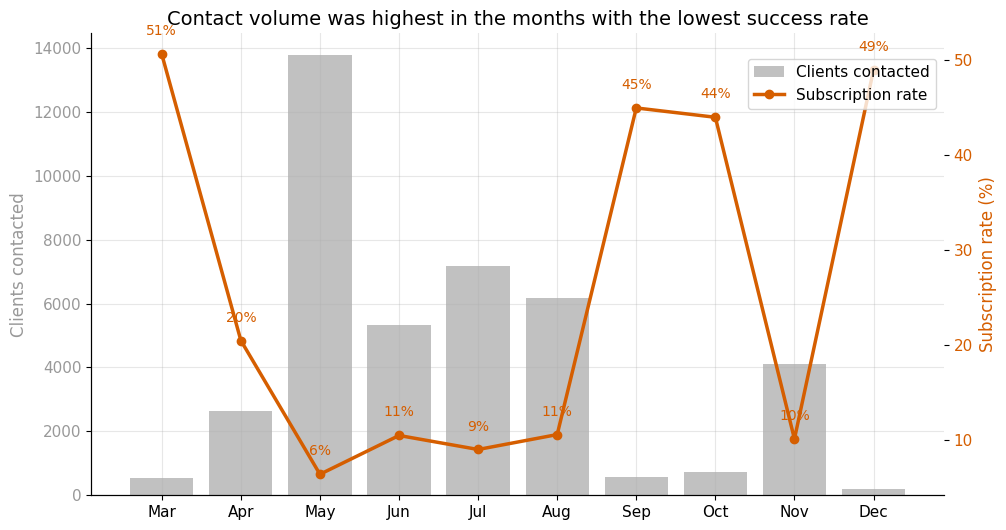

In [8]:
month_order = ['mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
month_labels = ['Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

monthly = df.groupby('month', observed=True).agg(
    contacted=('subscribed', 'size'),
    rate=('subscribed', 'mean')
).reindex(month_order)
monthly['rate'] *= 100

fig, ax1 = plt.subplots(figsize=(11, 6))

ax1.bar(month_labels, monthly['contacted'], color=PALETTE['grey'],
        alpha=0.6, label='Clients contacted')
ax1.set_ylabel('Clients contacted', color=PALETTE['grey'])
ax1.tick_params(axis='y', labelcolor=PALETTE['grey'])

ax2 = ax1.twinx()
ax2.plot(month_labels, monthly['rate'], color=PALETTE['red'],
         marker='o', linewidth=2.5, label='Subscription rate')
ax2.set_ylabel('Subscription rate (%)', color=PALETTE['red'])
ax2.tick_params(axis='y', labelcolor=PALETTE['red'])
ax2.grid(False)

for x, y in zip(month_labels, monthly['rate']):
    if pd.notna(y):
        ax2.text(x, y + 2, f'{y:.0f}%', ha='center', color=PALETTE['red'], fontsize=10)

ax1.set_title('Contact volume was highest in the months with the lowest success rate')
fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.85))

save_figure(fig, '02_monthly_volume_and_rate')
plt.show()

# Section 3 — Business Requirement 2: What Is Associated With Subscription

BR2 asks which client characteristics relate to subscription. These charts present the
findings from the hypothesis tests in Notebook 02 in a form a non-technical reader can
interpret directly.

## Chart 3: subscription rate by age band (H1)

Saved Data_Set/outputs/v1/figures/03_rate_by_age_band.png


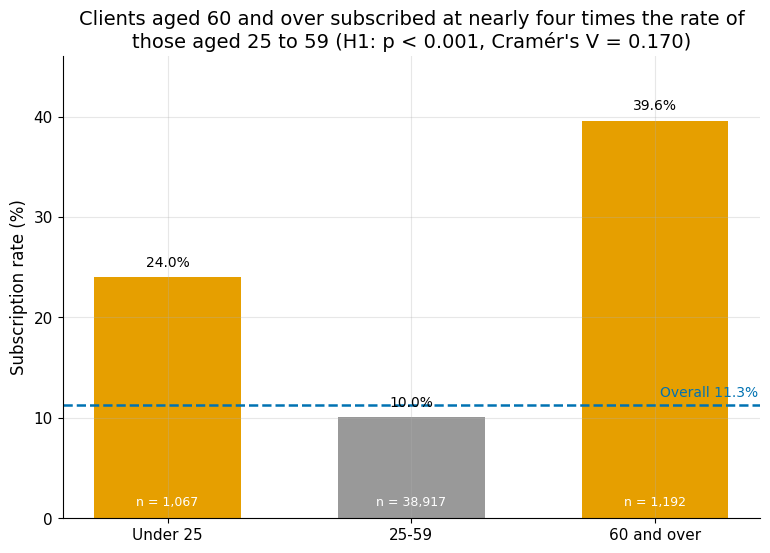

In [9]:
age_stats = df.groupby('age_band', observed=True).agg(
    contacted=('subscribed', 'size'),
    rate=('subscribed', 'mean')
)
age_stats['rate'] *= 100
age_stats = age_stats.reindex(['Under 25', '25-59', '60 and over'])

overall = df['subscribed'].mean() * 100

fig, ax = plt.subplots(figsize=(9, 6))
colours = [PALETTE['orange'], PALETTE['grey'], PALETTE['orange']]
ax.bar(age_stats.index, age_stats['rate'], color=colours, width=0.6)
label_bars(ax, age_stats['rate'], suffix='%', offset=0.8)

ax.axhline(overall, color=PALETTE['blue'], linestyle='--', linewidth=1.8)
ax.text(2.42, overall + 0.8, f'Overall {overall:.1f}%',
        color=PALETTE['blue'], ha='right', fontsize=10)

for i, n in enumerate(age_stats['contacted']):
    ax.text(i, 1.2, f'n = {n:,}', ha='center', fontsize=9, color='white')

ax.set_ylabel('Subscription rate (%)')
ax.set_title('Clients aged 60 and over subscribed at nearly four times the rate of\n'
             'those aged 25 to 59 (H1: p < 0.001, Cramér\'s V = 0.170)')
ax.set_ylim(0, 46)

save_figure(fig, '03_rate_by_age_band')
plt.show()

## Chart 4: education gradient (H2)

Saved Data_Set/outputs/v1/figures/04_rate_by_education.png


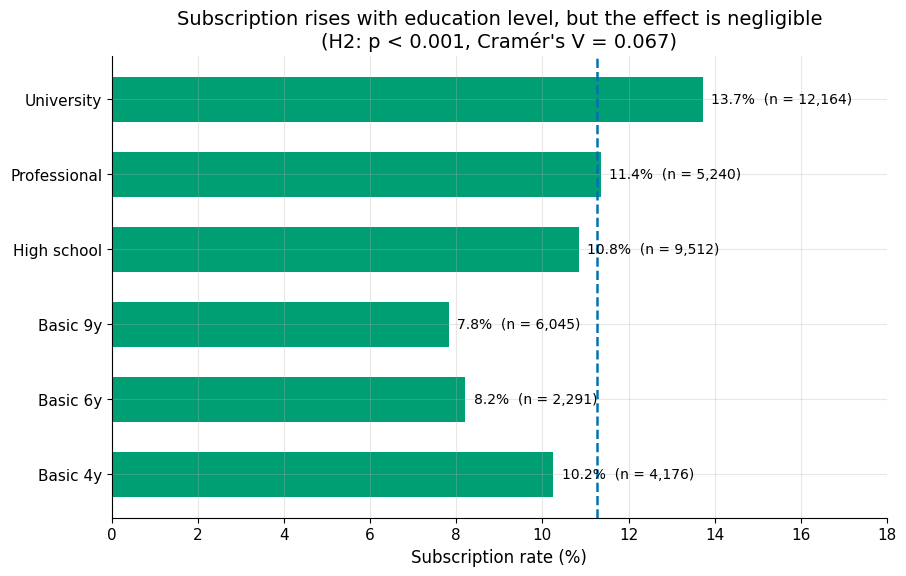

In [10]:
edu_order = ['basic.4y', 'basic.6y', 'basic.9y', 'high.school',
             'professional.course', 'university.degree']
edu_labels = ['Basic 4y', 'Basic 6y', 'Basic 9y', 'High school',
              'Professional', 'University']

edu = df[df['education'].isin(edu_order)].groupby('education', observed=True).agg(
    contacted=('subscribed', 'size'),
    rate=('subscribed', 'mean')
).reindex(edu_order)
edu['rate'] *= 100

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(edu_labels, edu['rate'], color=PALETTE['green'], height=0.6)

for i, (r, n) in enumerate(zip(edu['rate'], edu['contacted'])):
    ax.text(r + 0.2, i, f'{r:.1f}%  (n = {n:,})', va='center', fontsize=10)

ax.axvline(overall, color=PALETTE['blue'], linestyle='--', linewidth=1.8)
ax.set_xlabel('Subscription rate (%)')
ax.set_title('Subscription rises with education level, but the effect is negligible\n'
             '(H2: p < 0.001, Cramér\'s V = 0.067)')
ax.set_xlim(0, 18)

save_figure(fig, '04_rate_by_education')
plt.show()

## Chart 5: call duration by outcome (H5, leakage)

Saved Data_Set/outputs/v1/figures/05_duration_leakage.png


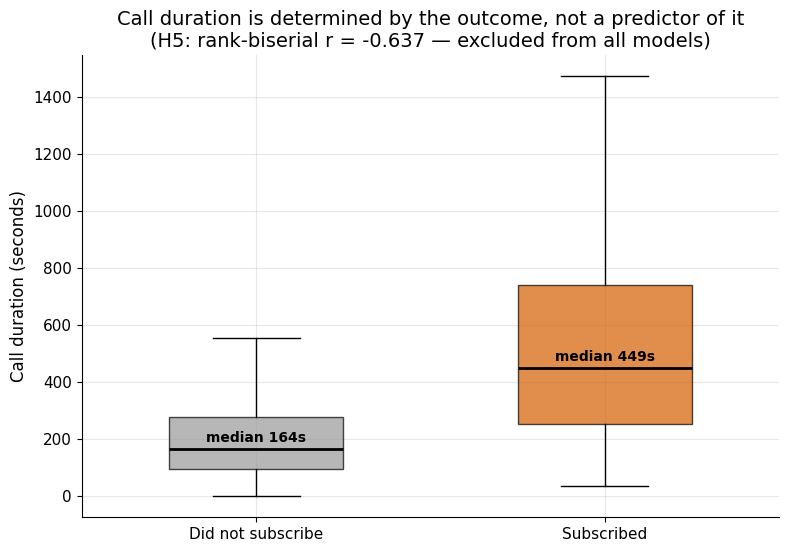

In [11]:
fig, ax = plt.subplots(figsize=(9, 6))

data = [df[df['subscribed'] == 0]['duration'],
        df[df['subscribed'] == 1]['duration']]

bp = ax.boxplot(data, labels=['Did not subscribe', 'Subscribed'],
                patch_artist=True, showfliers=False, widths=0.5)

for patch, colour in zip(bp['boxes'], [PALETTE['grey'], PALETTE['red']]):
    patch.set_facecolor(colour)
    patch.set_alpha(0.7)
for median in bp['medians']:
    median.set_color('black')
    median.set_linewidth(2)

for i, d in enumerate(data, start=1):
    ax.text(i, d.median() + 25, f'median {d.median():.0f}s',
            ha='center', fontsize=10, fontweight='bold')

ax.set_ylabel('Call duration (seconds)')
ax.set_title('Call duration is determined by the outcome, not a predictor of it\n'
             '(H5: rank-biserial r = -0.637 — excluded from all models)')

save_figure(fig, '05_duration_leakage')
plt.show()

## Chart 6: subscription rate heatmap, job by age band

Saved Data_Set/outputs/v1/figures/06_heatmap_job_by_age.png


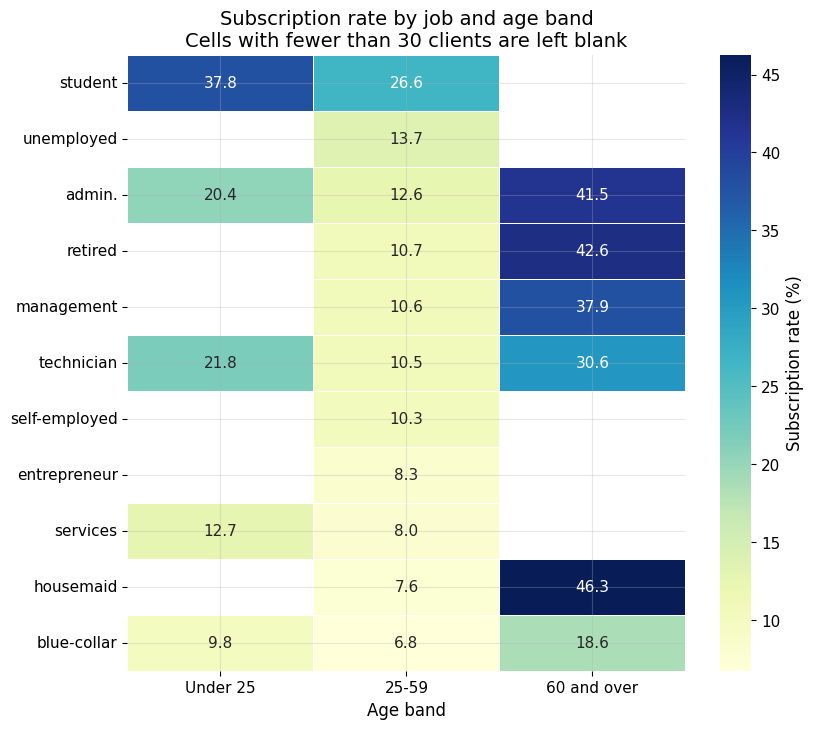

In [12]:
pivot = df.pivot_table(index='job', columns='age_band',
                       values='subscribed', aggfunc='mean', observed=True) * 100
counts = df.pivot_table(index='job', columns='age_band',
                        values='subscribed', aggfunc='size', observed=True)

# Suppress cells with fewer than 30 records — too small to interpret
pivot = pivot.where(counts >= 30)
pivot = pivot[['Under 25', '25-59', '60 and over']].sort_values('25-59', ascending=False)

fig, ax = plt.subplots(figsize=(9, 8))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlGnBu',
            cbar_kws={'label': 'Subscription rate (%)'},
            linewidths=0.5, linecolor='white', ax=ax)

ax.set_title('Subscription rate by job and age band\n'
             'Cells with fewer than 30 clients are left blank')
ax.set_xlabel('Age band')
ax.set_ylabel('')

save_figure(fig, '06_heatmap_job_by_age')
plt.show()

# Section 4 — Business Requirement 4: Communicating Significance Against Effect Size

BR4 requires the analysis to be interpretable by a non-technical audience. The most likely
misreading of this project is that any result marked "significant" is important. This chart
addresses that directly by plotting the effect size of each hypothesis rather than its
p-value, and is the chart the dashboard leads with when explaining method.

## Chart 7: effect sizes

Saved Data_Set/outputs/v1/figures/07_effect_sizes.png


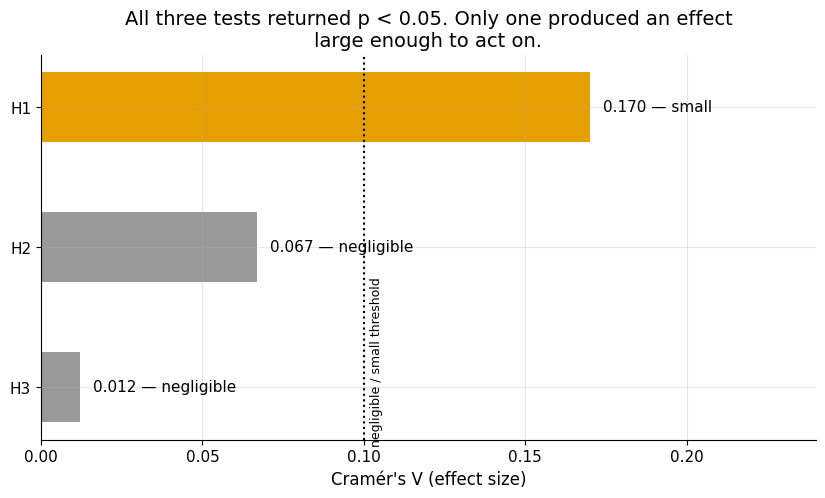

In [13]:
plot_data = results[results['effect_measure'] == "Cramér's V"].copy()
plot_data = plot_data.sort_values('effect_size')

fig, ax = plt.subplots(figsize=(10, 5))

colour_map = {'negligible': PALETTE['grey'], 'small': PALETTE['orange'],
              'moderate': PALETTE['red'], 'large': PALETTE['purple']}
colours = [colour_map.get(i, PALETTE['grey']) for i in plot_data['interpretation']]

ax.barh(plot_data['hypothesis'], plot_data['effect_size'], color=colours, height=0.5)

for i, (v, label) in enumerate(zip(plot_data['effect_size'],
                                   plot_data['interpretation'])):
    ax.text(v + 0.004, i, f'{v:.3f} — {label}', va='center', fontsize=11)

ax.axvline(0.10, color='black', linestyle=':', linewidth=1.5)
ax.text(0.102, -0.42, 'negligible / small threshold', fontsize=9, rotation=90,
        va='bottom')

ax.set_xlabel("Cramér's V (effect size)")
ax.set_title('All three tests returned p < 0.05. Only one produced an effect\n'
             'large enough to act on.')
ax.set_xlim(0, 0.24)

save_figure(fig, '07_effect_sizes')
plt.show()

In [14]:
figures = sorted(os.listdir(fig_dir))
print(f"{len(figures)} figures written to {fig_dir}:\n")
for f in figures:
    print(f"  {f}")

7 figures written to Data_Set/outputs/v1/figures:

  01_outcome_distribution.png
  02_monthly_volume_and_rate.png
  03_rate_by_age_band.png
  04_rate_by_education.png
  05_duration_leakage.png
  06_heatmap_job_by_age.png
  07_effect_sizes.png


### Findings

# Push files to Repo

* In cases where you don't need to push files to Repo, you may replace this section with "Conclusions and Next Steps" and state your conclusions and next steps.

In [ ]:
import os
try:
  # create your folder here
  # os.makedirs(name='')
except Exception as e:
  print(e)
